In [15]:
import pandas as pd 
import numpy as np
import os 
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.ticker import MaxNLocator
from sklearn import metrics

In [16]:
df = pd.read_csv("ai_chorales.csv")

In [17]:
df.shape

(5900, 17)

# Data prep

In [18]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%dT%H-%M-%S-%fZ", utc=True)

In [19]:
df = df[[
    'participant_id', 
    'timestamp',
    'age',
    'musical_experience',
    'plays_instrument',
    'sings_in_choir',
    'uses_ai_weekly',
    'confidence_before',
    'confidence_after',
    'difficulty',
    # free_feedback,
    'stimulus',
    'response',  
    'correct',
    'correct_response',
    'rt', 
    # 'training',
        ]]

In [20]:
# transform to 1 column per participant for categorical analyses
unique_participants = df.drop_duplicates(subset=["participant_id"])
print(f"Number of participants: {len(unique_participants)}")



Number of participants: 295


# Data eval

In [9]:
# ================
# AVERAGE DURATION
# ================
sum_rt = df["rt"].sum()

avg_completion_time = (round(sum_rt / len(unique_participants) / 1000 / 60, 2))

print(f" The average duration of the experiment is {avg_completion_time} minutes")

 The average duration of the experiment is 3.96 minutes


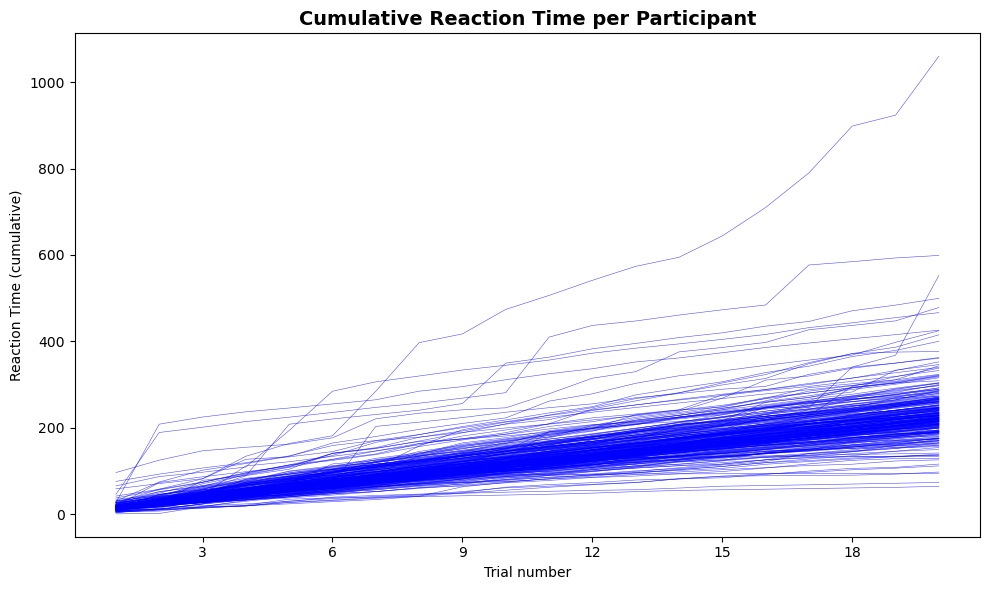

In [ ]:
# =====================================
# REACTION TIME DEVELOPMENT OVER TRIALS
# =====================================

df = df.copy()

df["trial_number"] = df.groupby("participant_id").cumcount() + 1
df["cumulative_rt_sec"] = (
    df.groupby("participant_id")["rt"]
    .cumsum() / 1000
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="trial_number",
    y="cumulative_rt_sec",
    units="participant_id",
    estimator=None,
    color="blue",
    alpha=0.7,
    linewidth=0.4,
    legend=False
)
plt.xlabel("Trial number")
plt.ylabel("Reaction Time (cumulative)")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("Cumulative Reaction Time per Participant", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

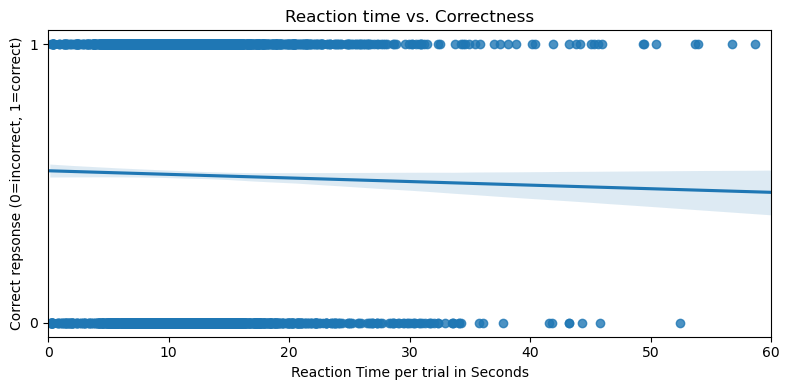

-0.0203073934535544


In [80]:
# ===============================
# ACCURACY BASED ON REACTION TIME
# ===============================

df = df.copy()

df["rt_sec"] = df["rt"] / 1000
df["correct_response"] = pd.to_numeric(df["correct_response"], errors="coerce").astype(int)

plt.figure(figsize=(8, 4))

sns.regplot(
    data=df,
    x="rt_sec",
    y="correct_response"
)
plt.xlabel("Reaction Time per trial in Seconds")
plt.ylabel("Correct repsonse (0=incorrect, 1=correct)")
plt.title("Reaction time vs. Correctness")
plt.yticks([0, 1])
plt.xlim(0, 60)
plt.tight_layout()
plt.show()
corr = df["rt_sec"].corr(df["correct_response"])
print(corr)

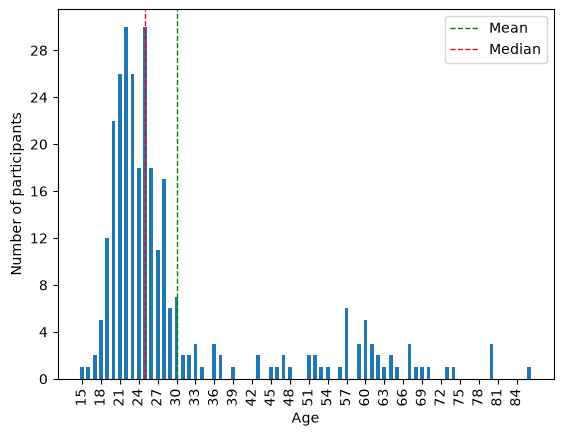

In [22]:
# ================
# AGE DISTRIBUTION 
# ================

unique_ages = unique_participants["age"]

age_min, age_max = int(unique_ages.min()), int(unique_ages.max())
unique_ages.plot(
    kind="hist", 
    bins=range(age_min, age_max + 2), 
    align='left',
    rwidth=0.6, # Adds a slight gap between bars for readability
    ylabel="Number of participants", 
    xlabel="Age",
    title=None,
    label="_nolegend_"
)



plt.xticks(range(age_min, age_max + 1, 3), rotation=90)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.axvline(
  x=np.nanmean(df.age), 
  color = 'g',
  linestyle = '--', 
  linewidth = 1,
  label="Mean"
)
plt.axvline(
  x=np.nanmedian(df.age), 
  color = 'r',
  linestyle = '--', 
  linewidth = 1,
  label="Median"
)
plt.legend()

plt.show()

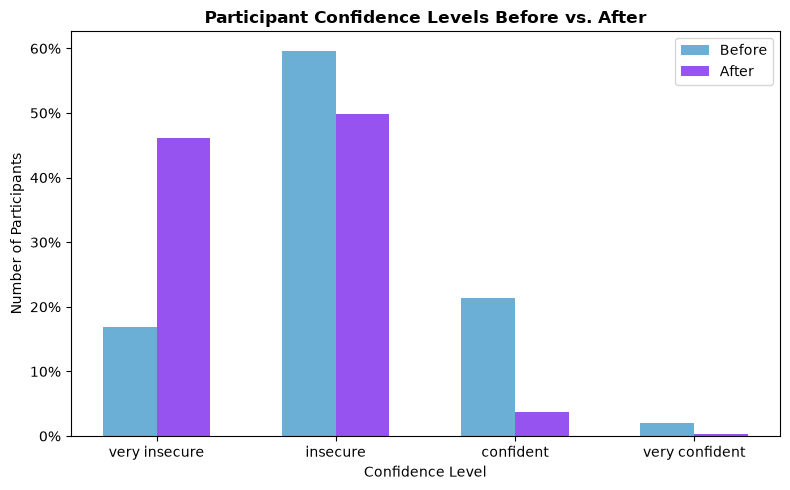

In [ ]:
# ==========================
# CONFIDENCE BEFORE VS AFTER
# ==========================

df = pd.read_csv("poster/ai_chorales.csv")

# normalize & map labels
translation = {"sehr unsicher": "very insecure",
               "unsicher":"insecure",
               "sicher":"confident",
               "sehr sicher":"very confident"}

categories = ["very insecure", "insecure", "confident", "very confident"]

unique_participants = df.drop_duplicates(subset=["participant_id"]).copy()

for col in ["confidence_before", "confidence_after"]:
    unique_participants[col] = unique_participants[col].astype(str).str.strip().str.lower().map(translation)

summary = pd.DataFrame(
    {
        "Before": unique_participants["confidence_before"].value_counts(normalize=True),
        "After": unique_participants["confidence_after"].value_counts(normalize=True)
    }
).reindex(["very insecure", "insecure", "confident", "very confident"])

x = np.arange(len(categories))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.bar(x - width / 2, summary["Before"], width, label="Before", color="#6baed6")
ax.bar(x + width / 2, summary["After"], width, label="After", color="#9753f0")

ax.set_title(
    "Participant Confidence Levels Before vs. After", fontweight="bold"
)
ax.set_xlabel("Confidence Level")
ax.set_ylabel("Number of Participants")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.show()

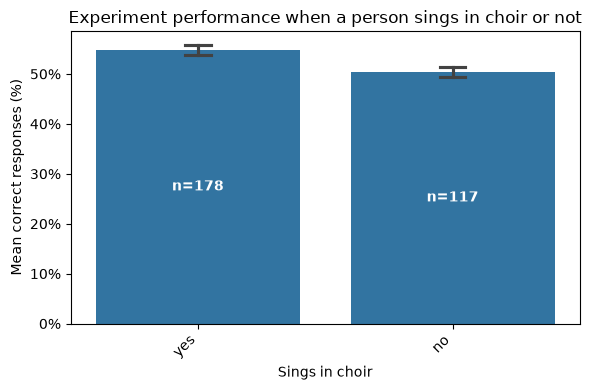

In [75]:
# =============================================
# AVERAGE CORRECT RESPONSES BY "sings_in_choir"
# =============================================
translation_dict = {"ja": "yes", "nein": "no"}

df["sings_in_choir"] = df["sings_in_choir"].map(translation_dict)

# Calculate accuracy proportion (mean) per participant
participant_summary = (
    df.groupby(["participant_id", "sings_in_choir"], as_index=False)[
        "correct_response"
    ].mean()
)

# Count participants per group for labels
counts = participant_summary["sings_in_choir"].value_counts()

order = ["yes", "no"]

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=participant_summary,
    x="sings_in_choir",
    order=order,
    y="correct_response",
    errorbar="se",
    capsize=0.1,
)

# Format y-axis values as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Add total participant counts inside each bar
bar_labels = [f"n={counts.get(cat, 0)}" for cat in order]
ax.bar_label(ax.containers[0], labels=bar_labels, label_type="center", color="white", fontweight="bold")

plt.ylabel("Mean correct responses (%)")
plt.xlabel("Sings in choir")
plt.title("Experiment performance when a person sings in choir or not")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

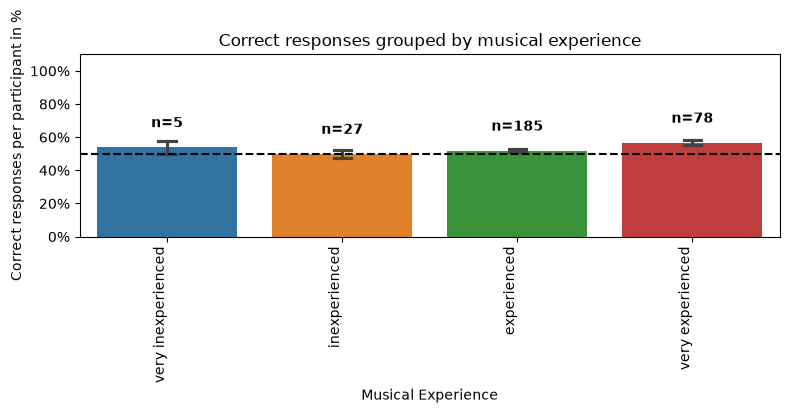

In [102]:
# ==============================
# MUSICAL EXPERIENCE VS ACCURACY
# ==============================

df = pd.read_csv("ai_chorales.csv")

translation_dict = {
    "sehr unerfahren": "very inexperienced",
    "unerfahren": "inexperienced",
    "erfahren": "experienced",
    "sehr erfahren": "very experienced",
}

df["musical_experience"] = df["musical_experience"].map(translation_dict)

participant_summary = df.groupby(
    ["participant_id", "musical_experience"], as_index=False
)["correct_response"].mean()

order = ["very inexperienced", "inexperienced", "experienced", "very experienced"]

counts = participant_summary["musical_experience"].value_counts()

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=participant_summary,
    x="musical_experience",
    y="correct_response",
    order=order,
    errorbar="se",
    capsize=0.1,
    hue="musical_experience",
    hue_order=order,
    legend=False,
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0.5, color="black", linestyle="--")
ax.set_ylim(0, 1.1)

# Annotate each bar manually using ax.patches to avoid container issues
for patch, cat in zip(ax.patches, order):
    height = patch.get_height()
    n_val = counts.get(cat, 0)
    ax.annotate(
        f"n={n_val}",
        xy=(patch.get_x() + patch.get_width() / 2, height),
        xytext=(0, 12),  # offset above error bar
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("Correct responses per participant in %")
plt.xlabel("Musical Experience")
plt.title("Correct responses grouped by musical experience")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

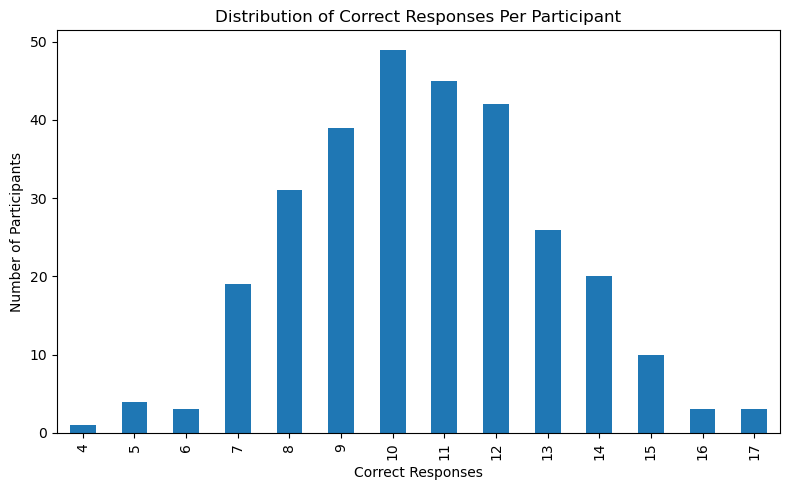

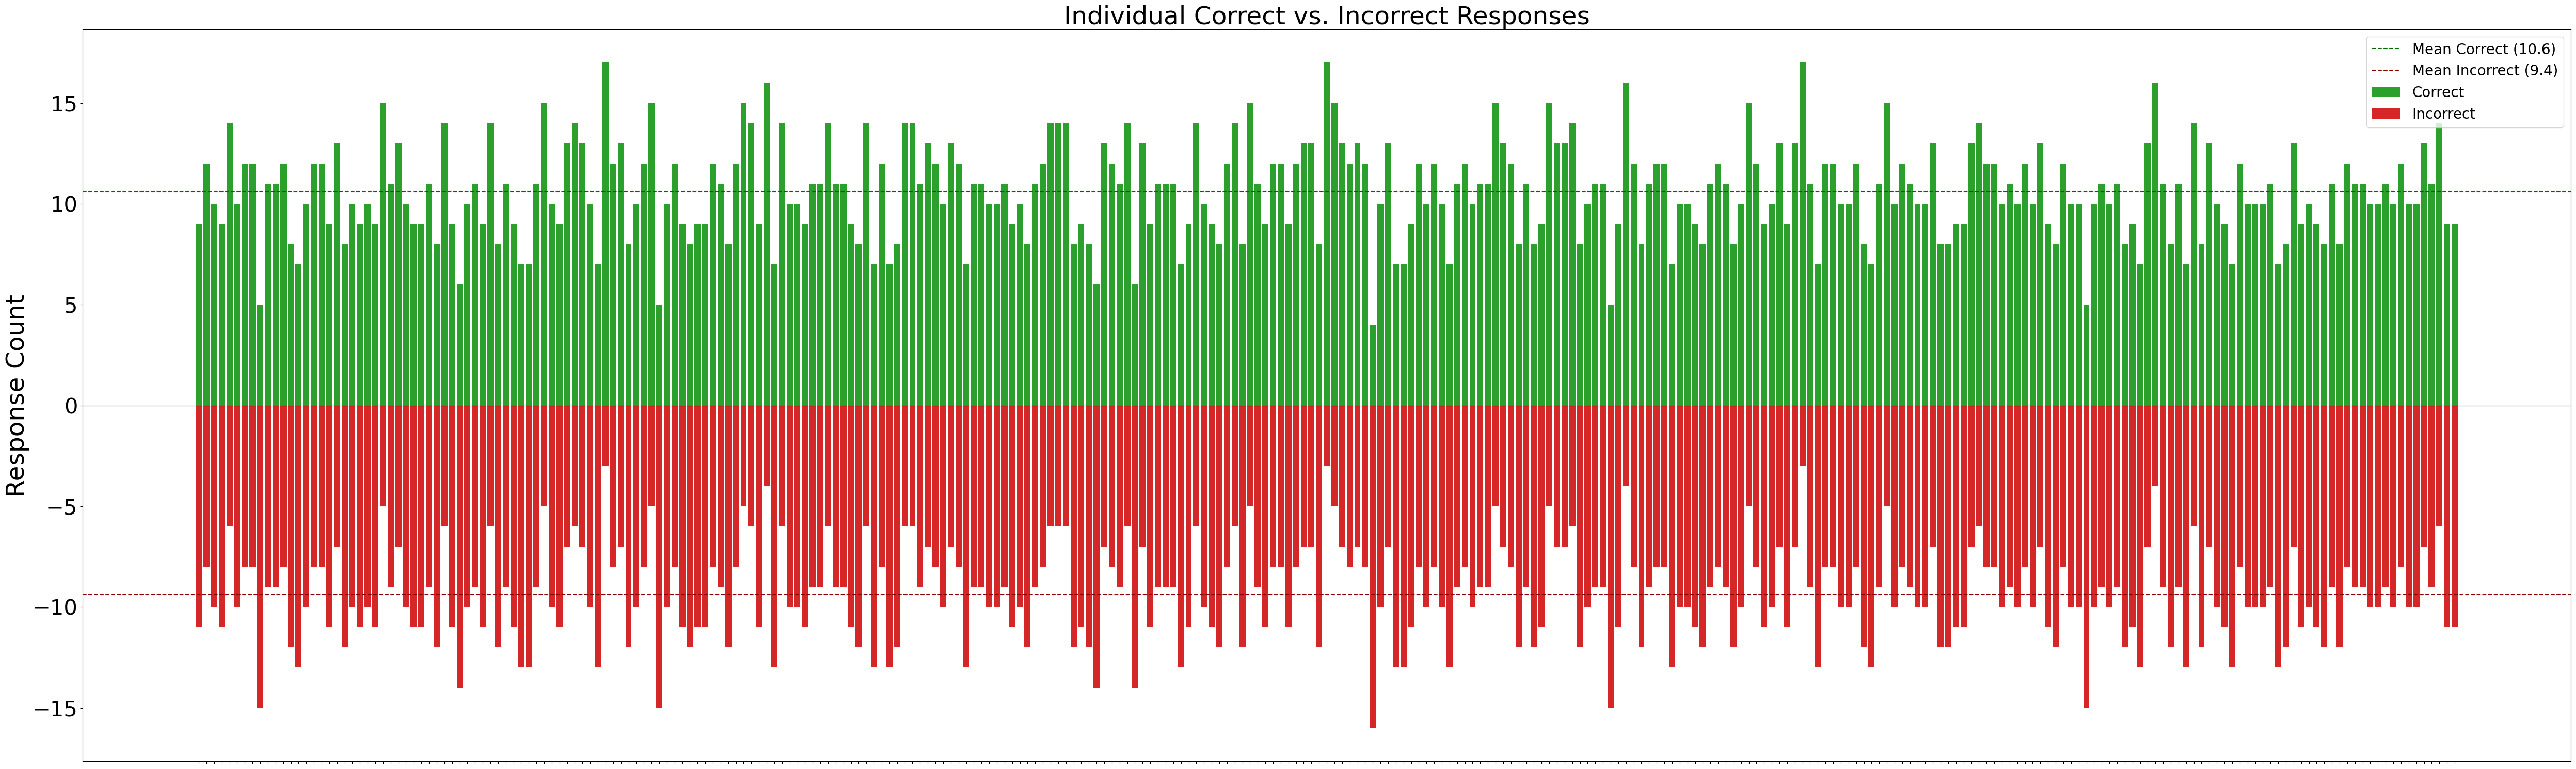

In [21]:
# =================================================
# DISTRIBUTION OF CORRECT RESPONSES PER PARTICIPANT
# =================================================

# 1. Aggregate correct, total, and incorrect counts
summary = df.groupby("participant_id")["correct_response"].agg(
    correct="sum",
    total="count"
).reset_index()

summary["incorrect"] = summary["total"] - summary["correct"]


# Plot 1: Distribution of correct responses

plt.figure(figsize=(8, 5))
summary["correct"].value_counts().sort_index().plot(
    kind="bar", 
    xlabel="Correct Responses", 
    ylabel="Number of Participants",
    title="Distribution of Correct Responses Per Participant"
)
plt.tight_layout()
plt.show()


# Plot 2: Diverging Bar Chart (Correct vs. Incorrect)

fig, ax = plt.subplots(figsize=(50, 15))

x = np.arange(len(summary))

# Diverging bars
ax.bar(x, summary["correct"], label="Correct", color="#2ca02c")
ax.bar(x, -summary["incorrect"], label="Incorrect", color="#d62728")

# Mean reference lines
mean_corr = summary["correct"].mean()
mean_inc = summary["incorrect"].mean()

ax.axhline(mean_corr, color="darkgreen", linestyle="--", label=f"Mean Correct ({mean_corr:.1f})")
ax.axhline(-mean_inc, color="darkred", linestyle="--", label=f"Mean Incorrect ({mean_inc:.1f})")

# Formatting
ax.axhline(0, color="black", linewidth=0.8)  # Center line
ax.set_xticks(x)
ax.set_xticklabels(summary["participant_id"], rotation=45, ha="right", visible=False)
ax.set_ylabel("Response Count", fontsize=35)

ax.tick_params(axis="y", labelsize=30)
ax.set_title("Individual Correct vs. Incorrect Responses", fontsize=35)
ax.legend(loc="upper right", fontsize=20)

plt.tight_layout()
plt.show()

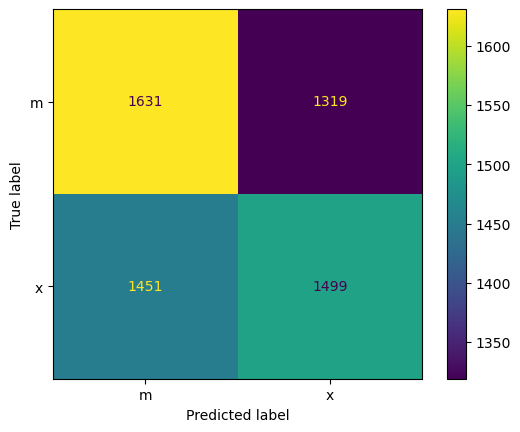

In [106]:
actual = df["correct"]
predicted = df["response"]

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels = ["m", "x"])

cm_display.plot()
plt.show()

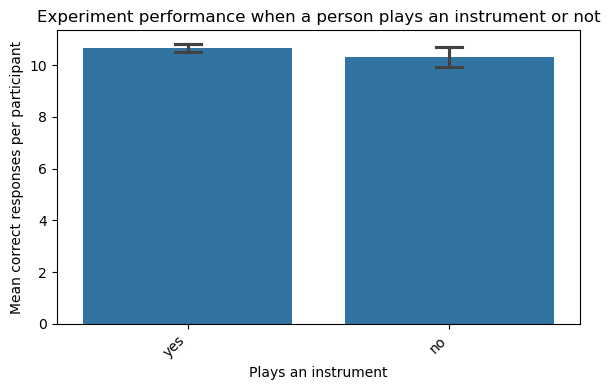

In [18]:
# ===============================================
# AVERAGE CORRECT RESPONSES BY "plays_instrument"
# ===============================================
translation_dict = {"ja": "yes", "nein": "no"}

df["plays_instrument"] = df["plays_instrument"].map(translation_dict)

participant_summary = (
    df.groupby(["participant_id", "plays_instrument"], as_index=False)["correct_response"]
    .sum()
)

order = ["yes", "no"]

plt.figure(figsize=(6, 4))
sns.barplot(
    data=participant_summary,
    x="plays_instrument",
    order=order,
    y="correct_response",
    errorbar="se",
    capsize=0.1
)
plt.ylabel("Mean correct responses per participant")
plt.xlabel("Plays an instrument")
plt.title("Experiment performance when a person plays an instrument or not")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

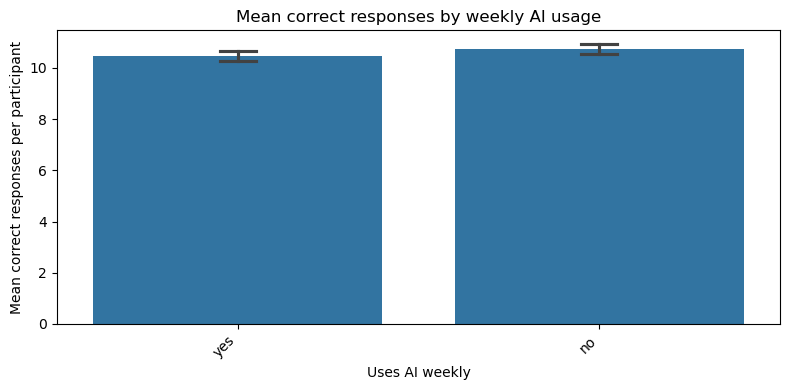

In [19]:
# ============================================
# AVERAGE CORRECT RESPONSES BY WEEKLY AI USAGE
# ============================================

translation_dict = {"ja": "yes", "nein": "no"}

df["uses_ai_weekly"] = df["uses_ai_weekly"].map(translation_dict)
participant_summary = (
    df.groupby(["participant_id", "uses_ai_weekly"], as_index=False)["correct_response"]
    .sum()
)


order = ["yes", "no"]
plt.figure(figsize=(8, 4))
sns.barplot(
    data=participant_summary,
    x="uses_ai_weekly",
    order=order,
    y="correct_response",
    errorbar="se",  # Options: 'ci' (confidence interval) or 'se' (standard error)
    capsize=0.1,
    legend=False
)

plt.ylabel("Mean correct responses per participant")
plt.xlabel("Uses AI weekly")
plt.title("Mean correct responses by weekly AI usage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

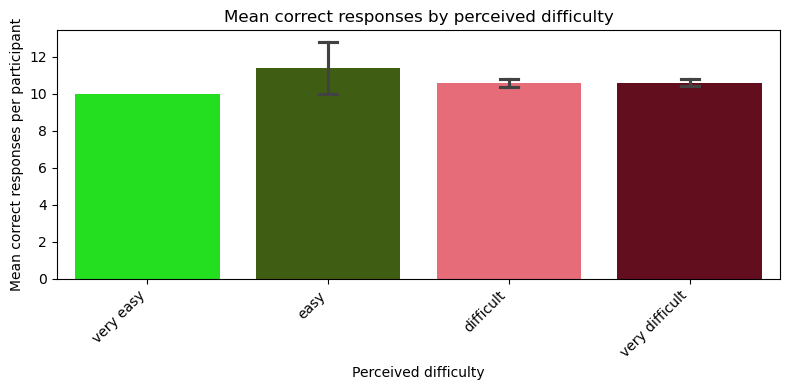

In [83]:
# ================================
# PERCEIVED DIFFICULTY VS ACCURACY
# ================================

translation_dict = {"sehr schwer": "very difficult",
               "schwer": "difficult",
               "einfach":"easy",
               "sehr einfach":"very easy"}

df["difficulty"] = df["difficulty"].map(translation_dict)

participant_summary = (
    df.groupby(["participant_id", "difficulty"], as_index=False)["correct_response"]
      .sum()
)


order = ["very easy", "easy", "difficult", "very difficult"]

colors = ["#04ff00", "#436908", "#fc576a", "#710015"]
plt.figure(figsize=(8, 4))
sns.barplot(
    data=participant_summary,
    x="difficulty",
    y="correct_response",
    order=order,   
    errorbar="se",     
    capsize=0.1,       
    hue="difficulty",
    hue_order=order,
    legend=False,
    palette=colors
)
plt.ylabel("Mean correct responses per participant")
plt.xlabel("Perceived difficulty")
plt.title("Mean correct responses by perceived difficulty")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Mean: 0.48228043143297383
Median:  0.4915254237288136


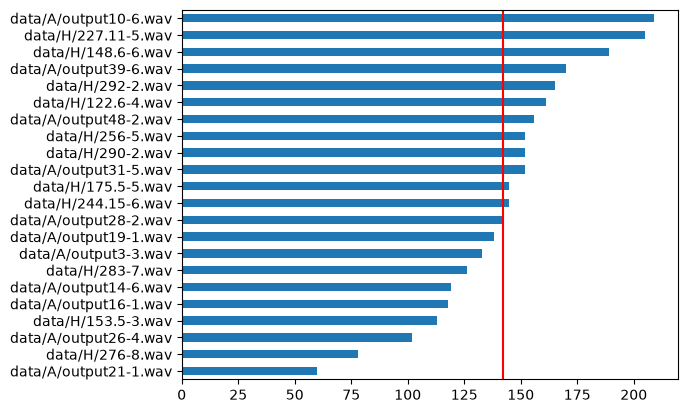

In [12]:
# ===================================================
# STIMULUS DISCRIMINATION ACCURACY (all participants)
# ===================================================

indices, values = zip(*[(n, g["correct_response"].sum()) for n, g in df.groupby("stimulus")])

responses_piece = pd.Series(values, index=indices).sort_index()

_, ax = plt.subplots()
responses_piece.sort_values().plot(kind="barh", ax=ax)
avg = responses_piece.mean()

ax.axvline(avg, c="red")
# ax.axvline(responses_piece.median(), c="green")
print("Mean:", avg / len(unique_participants))
print("Median: ", responses_piece.median() / len(unique_participants));

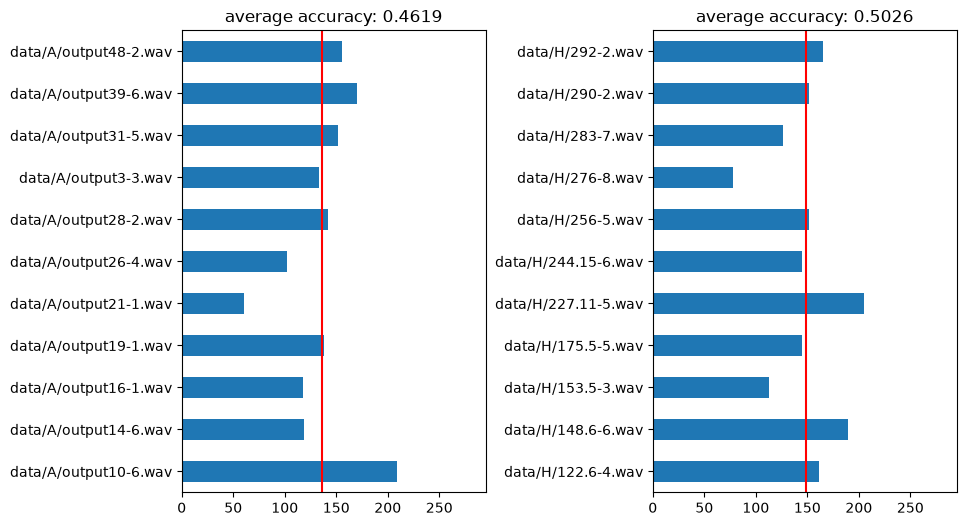

In [21]:
# ====================================================
# STIMULUS DISCRIMATION ACCURACY GROUPED BY AI / HUMAN 
# ====================================================

responses_A, responses_H = responses_piece[:11], responses_piece[11:]

_, axes = plt.subplots(1,2, figsize=(10,6), gridspec_kw={"wspace": .55})
for i, r in enumerate([responses_A, responses_H]):
    r.plot(kind="barh", ax=axes[i])
    avg = round(r.mean(), 3)
    axes[i].axvline(avg, c="red")
    axes[i].set_title(f"average accuracy: {round(avg/len(unique_participants), 4)}")
    axes[i].set_xlim(0,len(unique_participants))


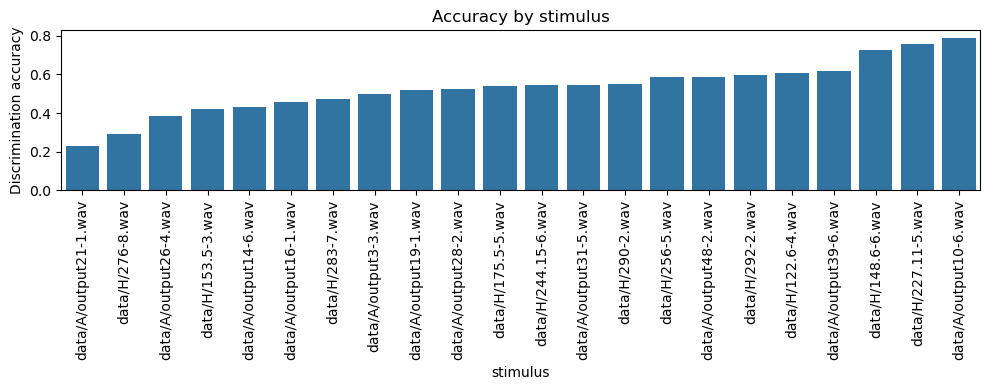

In [118]:

df2 = df.copy()

df2["true_label"] = df2["correct"].astype(str).str.strip().str.lower()
df2["pred_label"] = df2["response"].astype(str).str.strip().str.lower()

labels = sorted(set(df2["true_label"]).union(df2["pred_label"]))

# Store confusion matrices per stimulus
stimulus_cms = {}
stimulus_accuracy = []

for stim, g in df2.groupby("stimulus"):
    cm = metrics.confusion_matrix(
        g["true_label"],
        g["pred_label"],
        labels=labels
    )

    stimulus_cms[stim] = cm

    total = cm.sum()
    correct = cm.diagonal().sum()
    accuracy = correct / total if total else np.nan

    stimulus_accuracy.append((stim, accuracy))

# Convert to a table
stimulus_accuracy = pd.DataFrame(
    stimulus_accuracy,
    columns=["stimulus", "accuracy"]
).sort_values("accuracy", ascending=True)

plt.figure(figsize=(10, 4))
sns.barplot(data=stimulus_accuracy, x="stimulus", y="accuracy")
plt.xticks(rotation=90)
plt.ylabel("Discrimination accuracy")
plt.title("Accuracy by stimulus")
plt.tight_layout()
plt.show()

# TODO:

## Reaction time vs correctness
 test whether faster responses are more or less likely to be correct

## Age vs accuracy
?

## Create confusion matrix with the stimuli

## Regression model?